# JAEE — Fig. 1: Arsitektur Sistem Peringatan Dini

Menghasilkan `figures-jaee/fig1_arsitektur.(png|pdf)`. Diagram blok ini digambar dengan matplotlib supaya bisa dibuat ulang otomatis; kalau ingin tampilan lebih rapi, gambar ulang di draw.io/Figma dengan isi blok yang sama.

In [1]:
import warnings, sys, json, pathlib
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Semua gambar/JSON artikel JAEE disimpan di sini (relatif terhadap folder model/)
FIG = pathlib.Path("../figures-jaee")
FIG.mkdir(exist_ok=True)

# Gaya sesuai template JAEE: Times New Roman 8 pt, kolom 3,5 in / halaman 7,16 in, 300 dpi
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8, "legend.fontsize": 7,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "mathtext.fontset": "stix",
})
COL_W, PAGE_W = 3.5, 7.16

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")


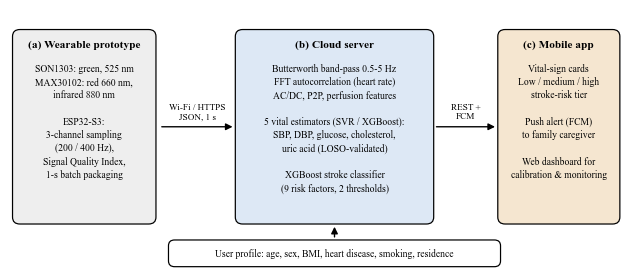

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(PAGE_W, 3.05))
ax.set_xlim(0, 100); ax.set_ylim(0, 44.5); ax.axis("off"); ax.grid(False)

def box(x, y, w, h, title, lines, fc):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.25,rounding_size=1.2",
                                fc=fc, ec="black", lw=.8))
    ax.text(x + w / 2, y + h - 1.6, title, ha="center", va="top", fontweight="bold", fontsize=7.4)
    ax.text(x + w / 2, y + h - 5.6, "\n".join(lines), ha="center", va="top",
            fontsize=6.3, linespacing=1.4)

def arrow(x1, y1, x2, y2, label="", dy=1.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=9,
                                 lw=.9, color="black"))
    if label:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + dy, label, ha="center", va="bottom", fontsize=6.0)

box(0.5, 8, 23, 33, "(a) Wearable prototype", [
    "SON1303: green, 525 nm",
    "MAX30102: red 660 nm,",
    "infrared 880 nm",
    "",
    "ESP32-S3:",
    "3-channel sampling",
    "(200 / 400 Hz),",
    "Signal Quality Index,",
    "1-s batch packaging"], "#EEEEEE")

box(37, 8, 32, 33, "(b) Cloud server", [
    "Butterworth band-pass 0.5-5 Hz",
    "FFT autocorrelation (heart rate)",
    "AC/DC, P2P, perfusion features",
    "",
    "5 vital estimators (SVR / XGBoost):",
    "SBP, DBP, glucose, cholesterol,",
    "uric acid (LOSO-validated)",
    "",
    "XGBoost stroke classifier",
    "(9 risk factors, 2 thresholds)"], "#DDE8F5")

box(80, 8, 19.5, 33, "(c) Mobile app", [
    "Vital-sign cards",
    "Low / medium / high",
    "stroke-risk tier",
    "",
    "Push alert (FCM)",
    "to family caregiver",
    "",
    "Web dashboard for",
    "calibration & monitoring"], "#F5E6D0")

ax.add_patch(FancyBboxPatch((26, 0.6), 54, 4.2, boxstyle="round,pad=0.2,rounding_size=1.0",
                            fc="white", ec="black", lw=.8))
ax.text(53, 2.7, "User profile: age, sex, BMI, heart disease, smoking, residence",
        ha="center", va="center", fontsize=6.3)

arrow(24.2, 24.5, 36.8, 24.5, "Wi-Fi / HTTPS\nJSON, 1 s", dy=1.0)
arrow(69.2, 24.5, 79.8, 24.5, "REST +\nFCM", dy=1.0)
arrow(53, 5.0, 53, 7.8)
save(fig, "fig1_arsitektur")
plt.show()